# MANU 465 Group Project - Concrete Compressive Strength Predictions

Team Memebers:

Callum Abraham [84939693]

Mriduti Datta [39804257]

Max Teplitskiy [70977434]

Eric Lu [25133307]

## Imports

In [125]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

#Utilities
from pathlib import Path
import pandas as pd
import numpy as np

#Plotting 
import matplotlib.pyplot as plt
import seaborn as sns

#Model Production
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error, r2_score
import xgboost as xgb
import tensorflow as tf


## Data Loading

In [126]:
#Load the dataset and look at the info of the dataset
csv_path = Path("concrete_data.xls")
dataset = pd.read_excel(csv_path)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

We can see that no data is missing from the file. 

## Data Visualization

In [127]:
#Investiage Sample data points in the dataset
display(dataset.sample(15,random_state=1))

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
339,297.16,0.00,117.54,174.80,9.52,1022.80,753.45,3,21.911547
244,238.05,0.00,94.11,186.66,7.00,949.91,847.01,3,19.932751
882,140.00,133.00,103.00,200.00,7.00,916.00,753.00,28,36.438807
567,203.50,135.70,0.00,185.70,0.00,1076.20,759.30,7,11.957582
923,162.00,207.00,172.00,216.00,10.00,822.00,638.00,28,39.844818
358,277.19,97.82,24.46,160.70,11.19,1061.70,782.46,100,66.948120
576,339.20,0.00,0.00,185.70,0.00,1069.20,754.30,7,21.179324
27,342.00,38.00,0.00,228.00,0.00,932.00,670.00,180,52.124386
994,374.30,0.00,0.00,190.20,6.70,1013.20,730.40,28,39.056057
563,210.70,316.10,0.00,185.70,0.00,977.00,689.30,7,21.819847


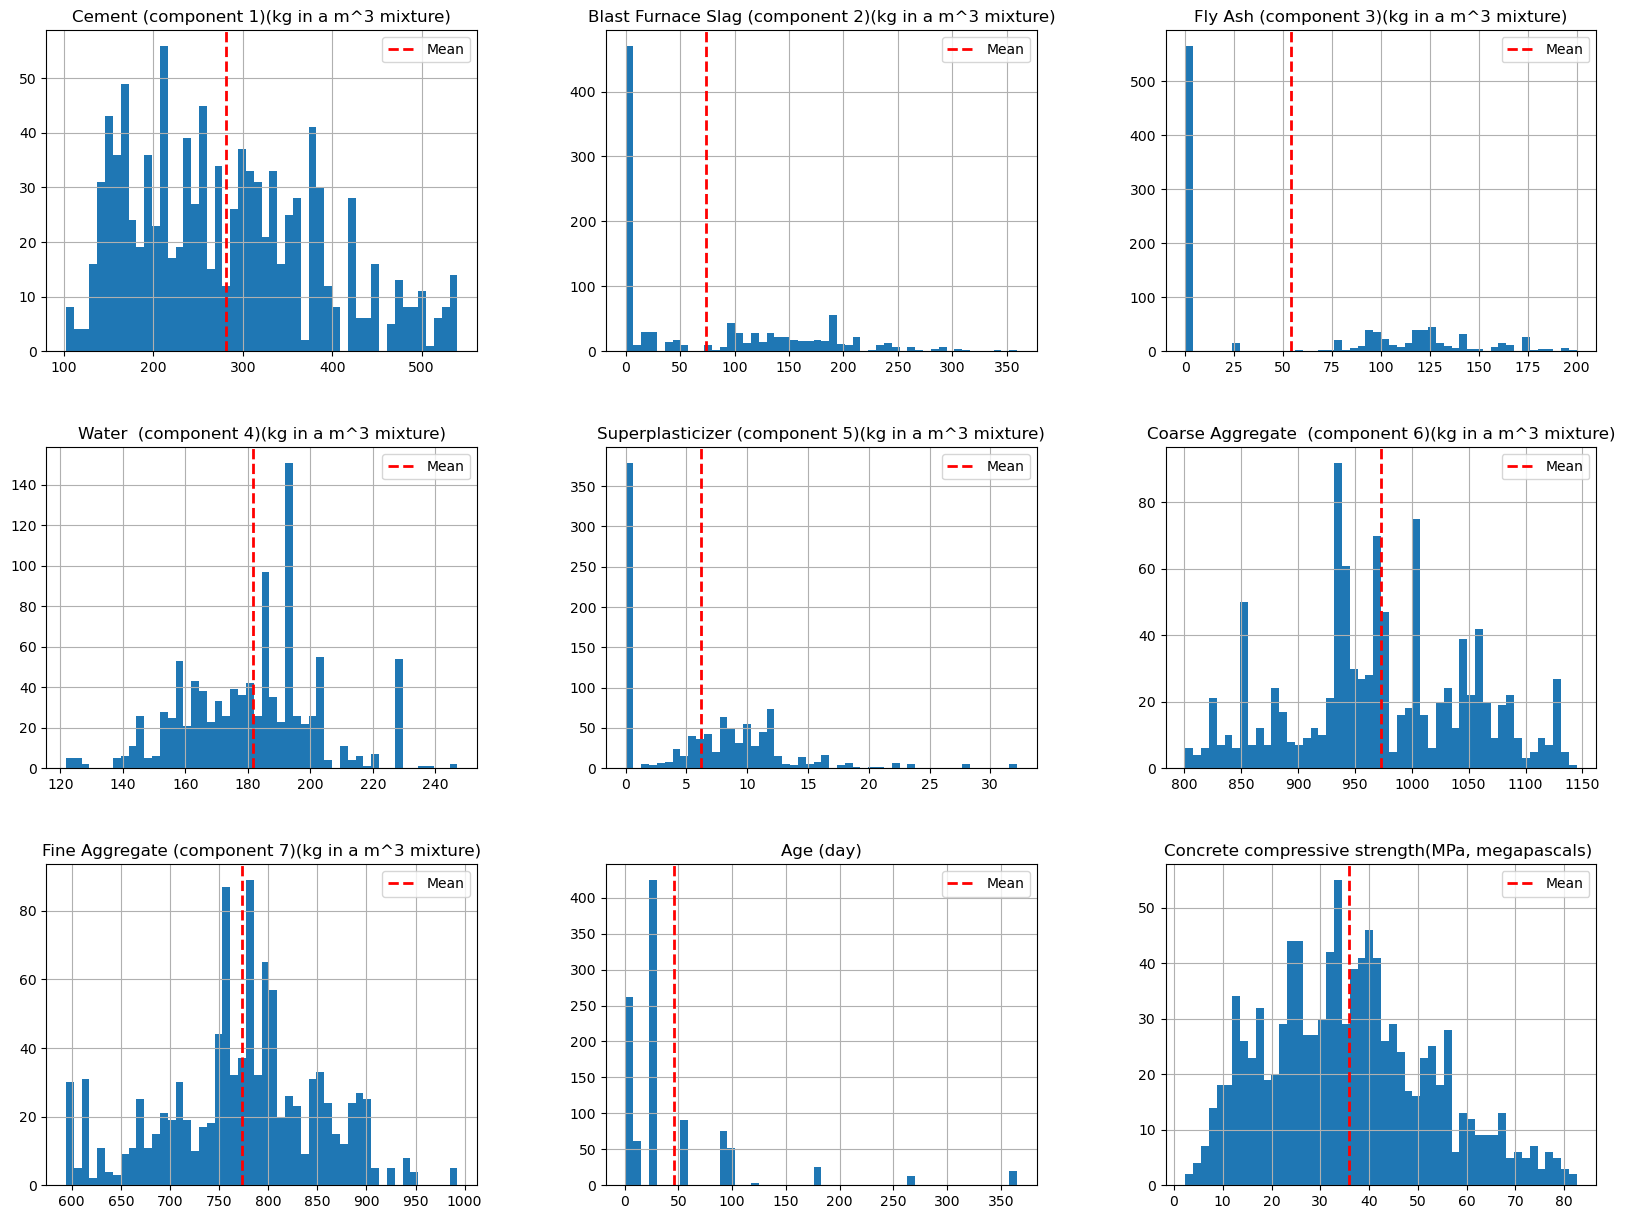

In [128]:
#Histogram of the plots of the dataset with mean shown as a vertical line
dataset.hist(bins=50, figsize=(20,15))
for i, ax in enumerate(plt.gcf().axes):
    ax.axvline(dataset.iloc[:, i].mean(), color='r', linestyle='dashed', linewidth=2, label='Mean')
    ax.legend()
plt.show()

## Train, Validation, and Test Split

We will use a standard 75/25 train test split for our data set

In [129]:
#Seperate the input (x) data T, AP, RH, and V data from the output (y) data EP 
y_data = dataset[[dataset.columns[-1]]]
x_data = dataset.iloc[:,:-1]

#Use the sklearn.model_selection train_test_split function to split the data, set random state = 1 for reproducibiltiy
x_train, x_test, y_train, y_test = train_test_split(x_data,y_data, test_size=0.25, random_state=1)

datasets_dict = {
    "X Training Data" : x_train,
    "X Test Data" : x_test,
    "Y Training Data" : y_train,
    "Y Test Data" : y_test
}

# Unscaled copy for ANN
ann_datasets_dict = datasets_dict.copy()

#Checks to see data after split:
for key, value in datasets_dict.items():
    print(f"The {key} Set Contains the Following:")
    rows = value.shape[0]
    cols = value.shape[1] if len(value.shape) > 1 else 1
    print(f"{rows} Rows and {cols} Columns")
    display(value.head())

The X Training Data Set Contains the Following:
772 Rows and 8 Columns


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
773,382.00,0.00,0.00,186.00,0.00,1047.00,739.00,28
890,158.00,0.00,195.00,220.00,11.00,898.00,713.00,28
233,213.72,98.05,24.51,181.71,6.86,1065.80,785.38,100
12,427.50,47.50,0.00,228.00,0.00,932.00,594.00,270
250,250.00,0.00,95.69,187.42,5.53,956.86,861.17,14


The X Test Data Set Contains the Following:
258 Rows and 8 Columns


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
339,297.16,0.0,117.54,174.80,9.52,1022.80,753.45,3
244,238.05,0.0,94.11,186.66,7.00,949.91,847.01,3
882,140.00,133.0,103.00,200.00,7.00,916.00,753.00,28
567,203.50,135.7,0.00,185.70,0.00,1076.20,759.30,7
923,162.00,207.0,172.00,216.00,10.00,822.00,638.00,28


The Y Training Data Set Contains the Following:
772 Rows and 1 Columns


,"Concrete compressive strength(MPa, megapascals)"
773,37.424757
890,8.535713
233,53.903234
12,43.012960
250,24.917663


The Y Test Data Set Contains the Following:
258 Rows and 1 Columns


,"Concrete compressive strength(MPa, megapascals)"
339,21.911547
244,19.932751
882,36.438807
567,11.957582
923,39.844818


## Apply Scaling

In [130]:
#Set the StandardScaler fucntion for easy implementation and set the output as a pandas.DataFrame
scaler_X = StandardScaler().set_output(transform='pandas')
scaler_Y = StandardScaler().set_output(transform='pandas')


#Scale the input and output data using the fit_transform fucntion
#Ensuring that test data is ONLY transformed and not fit to reduce leakage
y_scaler = None
for key, value in datasets_dict.items():
    if "Train" in key:
        if "X" in key:
            datasets_dict[key] = scaler_X.fit_transform(value)
        if "Y" in key:
            datasets_dict[key] = scaler_Y.fit_transform(value)
    if "Test" in key:
        if "X" in key:
            datasets_dict[key] = scaler_X.transform(value)
        if "Y" in key:
            datasets_dict[key] = scaler_Y.transform(value)

    print(f"The {key} Set Contains the Following:")
    print(f"{datasets_dict[key].shape[0]} Rows and {datasets_dict[key].shape[1]} Columns")
    display(datasets_dict[key].head())

The X Training Data Set Contains the Following:
772 Rows and 8 Columns


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
773,0.973909,-0.838013,-0.849277,0.217353,-1.034454,0.946961,-0.493885,-0.273743
890,-1.163875,-0.838013,2.177133,1.837597,0.855297,-0.962445,-0.825517,-0.273743
233,-0.632101,0.323154,-0.468880,0.012917,0.144063,1.187879,0.097696,0.903855
12,1.408147,-0.275489,-0.849277,2.218831,-1.034454,-0.526742,-2.343373,3.684296
250,-0.285857,-0.838013,0.635837,0.285022,-0.084425,-0.208166,1.064404,-0.502721


The X Test Data Set Contains the Following:
258 Rows and 8 Columns


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
339,0.164223,-0.838013,0.974950,-0.316374,0.601039,0.636842,-0.309574,-0.682632
244,-0.399904,-0.838013,0.611315,0.248805,0.168115,-0.297229,0.883792,-0.682632
882,-1.335662,0.737053,0.749288,0.884513,0.168115,-0.731778,-0.315314,-0.273743
567,-0.729638,0.769028,-0.849277,0.203057,-1.034454,1.321153,-0.234957,-0.617210
923,-1.125701,1.613405,1.820172,1.646980,0.683501,-1.936370,-1.782149,-0.273743


The Y Training Data Set Contains the Following:
772 Rows and 1 Columns


,"Concrete compressive strength(MPa, megapascals)"
773,0.114321
890,-1.604630
233,1.094820
12,0.446829
250,-0.629874


The Y Test Data Set Contains the Following:
258 Rows and 1 Columns


,"Concrete compressive strength(MPa, megapascals)"
339,-0.808743
244,-0.926485
882,0.055655
567,-1.401022
923,0.258319


## Model 1 Polynomial Regression

,MAE (MPa),RMSE (MPa),R2 Score,Features
Order,,,,
Degree 1,8.59,10.90,0.554640,8
Degree 2,6.08,8.02,0.758750,44
Degree 3,5.13,7.37,0.796113,164
Degree 4,27.75,103.73,-39.339790,494


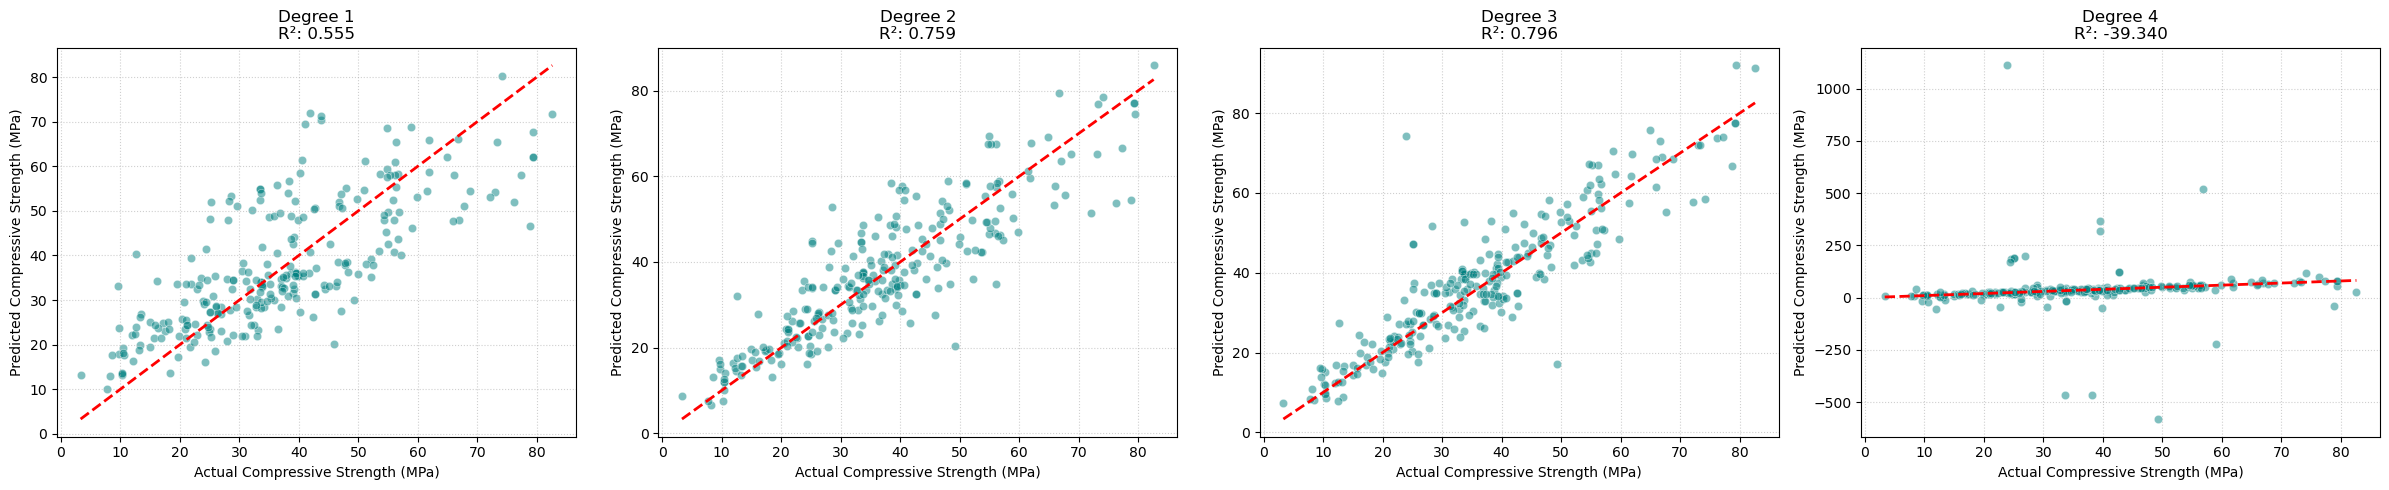

In [131]:
def full_polynomial_analysis(datasets, orders):
    X_train, X_test = datasets["X Training Data"], datasets["X Test Data"]
    y_train, y_test = datasets["Y Training Data"], datasets["Y Test Data"]
        
    stats_list = []
    fig, axes = plt.subplots(1, len(orders), figsize=(6 * len(orders), 5), sharey=False)
    
    if len(orders) == 1: 
        axes = [axes]

    for i, n in enumerate(orders):

        #Transform the data for polynomial fitting
        poly = PolynomialFeatures(degree=n, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
        
        #Define and fit the model
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)
        
        y_pred_mpa = scaler_Y.inverse_transform(pd.DataFrame(y_pred, columns=y_test.columns))
        y_test_mpa = scaler_Y.inverse_transform(y_test)

        y_true_1d = np.ravel(y_test_mpa)
        y_pred_1d = np.ravel(y_pred_mpa)
        mse = mean_squared_error(y_true_1d, y_pred_1d)
        mae = mean_absolute_error(y_true_1d, y_pred_1d)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true_1d, y_pred_1d)
        
        stats_list.append({
            "Order": f"Degree {n}",
            "MAE (MPa)": mae,
            "RMSE (MPa)": rmse,
            "R2 Score": r2,
            "Features": X_train_poly.shape[1]
        })
        
        sns.scatterplot(x=y_true_1d, y=y_pred_1d, ax=axes[i], alpha=0.5, color='teal')
        
        line_lims = [y_true_1d.min(), y_true_1d.max()]
        axes[i].plot(line_lims, line_lims, 'r--', lw=2)
        
        axes[i].set_title(f"Degree {n}\nR²: {r2:.3f}")
        axes[i].set_xlabel("Actual Compressive Strength (MPa)")
        axes[i].set_ylabel("Predicted Compressive Strength (MPa)")
        axes[i].grid(True, linestyle=':', alpha=0.6)

    summary_df = pd.DataFrame(stats_list).set_index("Order")
    styled_table = summary_df.style.highlight_max(subset=['R2 Score'], color="#90ee90") \
                                   .highlight_min(subset=['MAE (MPa)', 'RMSE (MPa)'], color='#90ee90') \
                                   .format("{:.2f}", subset=['MAE (MPa)', 'RMSE (MPa)'])
    
    display(styled_table)
    
    plt.tight_layout()
    plt.show()

full_polynomial_analysis(datasets_dict, [1, 2, 3, 4])

## Model 2 XGBoost

,MAE (MPa),RMSE (MPa),R2 Score
Depth,,,
Depth 3,3.79,5.21,0.898296
Depth 5,3.27,4.72,0.916551
Depth 7,3.27,4.92,0.909343
Depth 9,3.42,5.09,0.902984


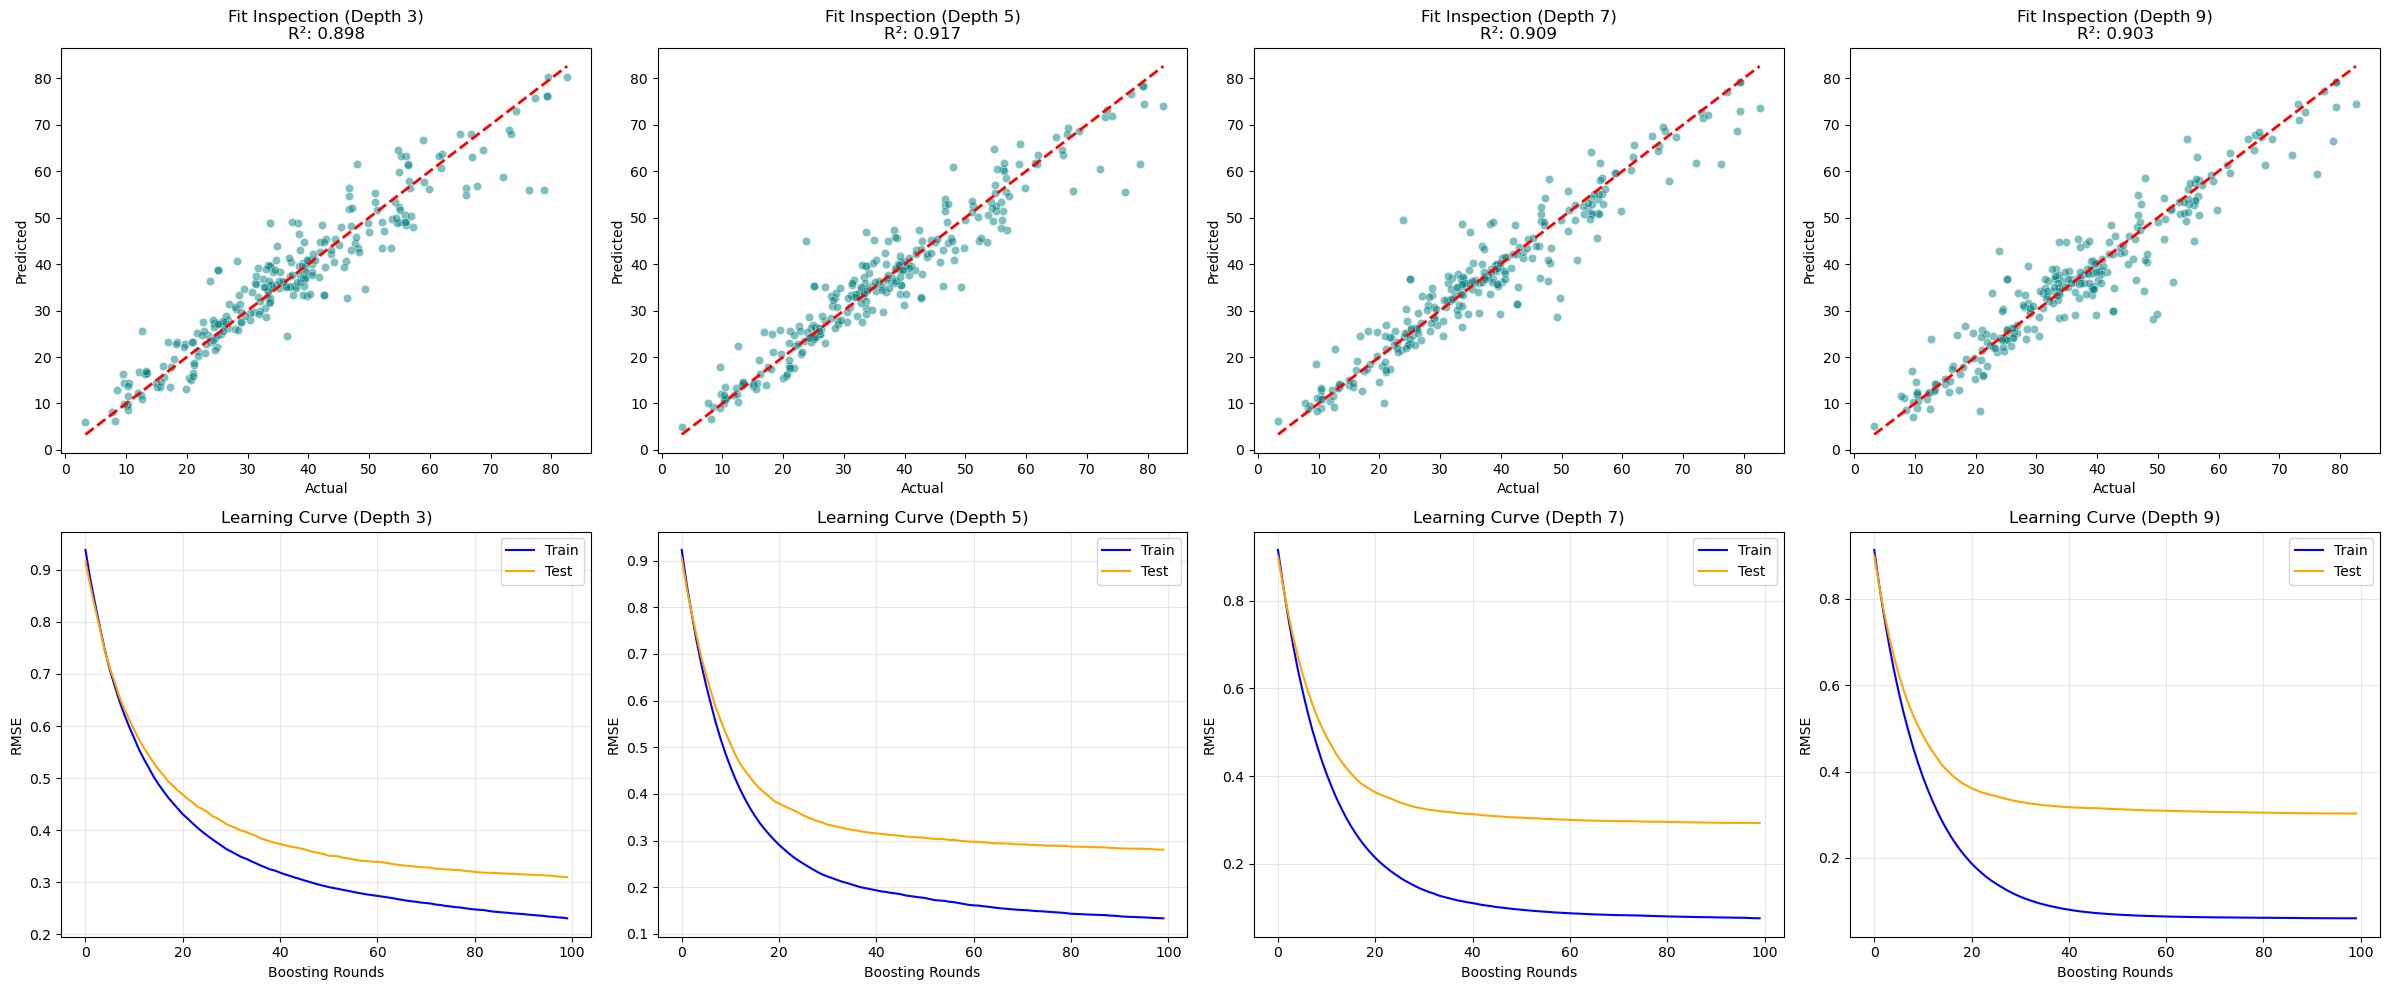

In [132]:
def xgboost_analysis(datasets, depths):
    X_train, X_test = datasets["X Training Data"], datasets["X Test Data"]
    y_train, y_test = datasets["Y Training Data"], datasets["Y Test Data"]
    
    # Use the y_scaler to inverse transform metrics back to MPa units    
    stats_list = []
    num_models = len(depths)
    
    fig, axes = plt.subplots(2, num_models, figsize=(6 * num_models, 10), sharey=False)
    
    if num_models == 1:
        axes = np.reshape(axes, (2, 1))

    for i, n in enumerate(depths):

        model = xgb.XGBRegressor(n_estimators=100, max_depth=n, learning_rate=0.1, random_state=1)
        model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
        
        results = model.evals_result()
        y_pred = model.predict(X_test)
        
        y_pred_mpa = scaler_Y.inverse_transform(pd.DataFrame(y_pred, columns=y_test.columns))
        y_test_mpa = scaler_Y.inverse_transform(y_test)

        y_true_1d = np.ravel(y_test_mpa)
        y_pred_1d = np.ravel(y_pred_mpa)
        mse = mean_squared_error(y_true_1d, y_pred_1d)
        mae = mean_absolute_error(y_true_1d, y_pred_1d)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true_1d, y_pred_1d)
        
        
        stats_list.append({
            "Depth": f"Depth {n}",
            "MAE (MPa)": mae,
            "RMSE (MPa)": rmse,
            "R2 Score": r2
        })
        
        sns.scatterplot(x=y_true_1d, y=y_pred_1d, ax=axes[0, i], alpha=0.5, color='teal')
        lims = [y_true_1d.min(), y_true_1d.max()]
        axes[0, i].plot(lims, lims, 'r--', lw=2)
        axes[0, i].set_title(f"Fit Inspection (Depth {n})\nR²: {r2:.3f}")
        axes[0, i].set_xlabel("Actual")
        axes[0, i].set_ylabel("Predicted")

        axes[1, i].plot(results['validation_0']['rmse'], label='Train', color='blue')
        axes[1, i].plot(results['validation_1']['rmse'], label='Test', color='orange')
        axes[1, i].set_title(f"Learning Curve (Depth {n})")
        axes[1, i].set_xlabel("Boosting Rounds")
        axes[1, i].set_ylabel("RMSE")
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)

    summary_df = pd.DataFrame(stats_list).set_index("Depth")
    styled_table = summary_df.style.highlight_max(subset=['R2 Score'], color="#90ee90") \
                                   .highlight_min(subset=['MAE (MPa)', 'RMSE (MPa)'], color='#90ee90') \
                                   .format("{:.2f}", subset=['MAE (MPa)', 'RMSE (MPa)'])
        
    display(styled_table)

    plt.tight_layout()
    plt.show()

xgboost_analysis(datasets_dict, [3, 5, 7, 9])

## Model 3 Artificial Neural Network

### Additional preprocessing: Augmentation

In [133]:
# Separate preprocessling pipeline with augemntation for ANN 
def preprocess(ann_datasets_dict, augment):
    X_train, X_test = ann_datasets_dict["X Training Data"], ann_datasets_dict["X Test Data"]
    y_train, y_test = ann_datasets_dict["Y Training Data"], ann_datasets_dict["Y Test Data"]

    # Scale on augmented data
    x_scaler = StandardScaler().set_output(transform='pandas')
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_test  = x_scaler.transform(X_test)
    y_train = y_scaler.fit_transform(y_train.values)
    y_test  = y_scaler.transform(y_test.values)

    if augment:
        np.random.seed(67)
        aug_factor = 20
        X_train_aug = np.tile(X_train, (aug_factor, 1)) + np.random.normal(0, 0.02, (len(X_train)*aug_factor, X_train.shape[1]))
        y_train_aug = np.tile(y_train.flatten(), aug_factor) + np.random.normal(0, 0.005, len(y_train)*aug_factor)
        print(f"Augmented training size: {len(X_train_aug)} (from {len(X_train)})")
        return X_train_aug, X_test, y_train_aug, y_test, y_scaler, x_scaler
    else:
        return X_train, X_test, y_train, y_test, y_scaler, x_scaler


### Main

In [134]:
def ann(datasets, augmentation):
    
    X_train, X_test, y_train, y_test, y_scaler, x_scaler = preprocess(datasets, augmentation)

    # Model Preparation
    reg = tf.keras.regularizers.l2(1e-5)
    act_func = 'elu'
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(units=8),
        tf.keras.layers.Dense(256, activation=act_func, kernel_regularizer=reg),
        tf.keras.layers.Dense(128, activation=act_func, kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(64, activation=act_func),
        tf.keras.layers.Dense(32, activation=act_func),
        tf.keras.layers.Dense(1)
    ])

    learning_rate = 0.001
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss='mse', metrics=['mae'])

    early_stop = tf.keras.callbacks.EarlyStopping(patience=30, restore_best_weights=True, monitor='val_mae')
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=15, min_lr=1e-7, monitor='val_mae')

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        batch_size=128, epochs=300, verbose=1,
        callbacks=[early_stop, reduce_lr]
    )
    model.summary()

    return history, model, y_scaler, x_scaler

ann_hist, model, y_scaler, x_scaler = ann(ann_datasets_dict, True) 

Augmented training size: 15440 (from 772)
Epoch 1/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - loss: 0.3548 - mae: 0.4156 - val_loss: 0.5299 - val_mae: 0.6130 - learning_rate: 0.0010
Epoch 2/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1399 - mae: 0.2863 - val_loss: 0.3508 - val_mae: 0.5002 - learning_rate: 0.0010
Epoch 3/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1183 - mae: 0.2621 - val_loss: 0.2549 - val_mae: 0.4088 - learning_rate: 0.0010
Epoch 4/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1088 - mae: 0.2525 - val_loss: 0.1488 - val_mae: 0.3099 - learning_rate: 0.0010
Epoch 5/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0959 - mae: 0.2349 - val_loss: 0.2024 - val_mae: 0.3340 - learning_rate: 0.0010
Epoch 6/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0933 - mae: 0.2342 - val_loss: 0.1399 - val_mae: 0.2757 - learning_rate: 0.0010
Epoch 7/300
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0817 - mae: 0.2178 - val_loss

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,949 (538.87 KB)

 Trainable params: 45,897 (179.29 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 91,796 (358.58 KB)

### Training Results

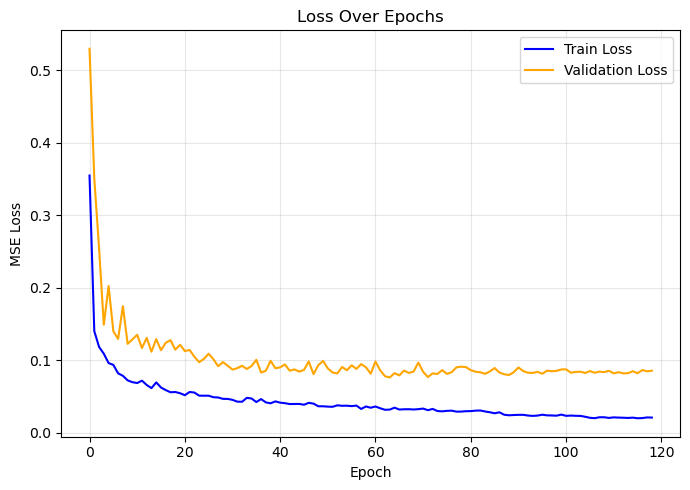

In [135]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(ann_hist.history['loss'], label='Train Loss', color='blue')
ax.plot(ann_hist.history['val_loss'], label='Validation Loss', color='orange')
ax.set_title('Loss Over Epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Model Evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step
MAE:  2.9291 MPa
MSE:  21.6733 MPa²
RMSE: 4.6555 MPa
R²:   0.9187


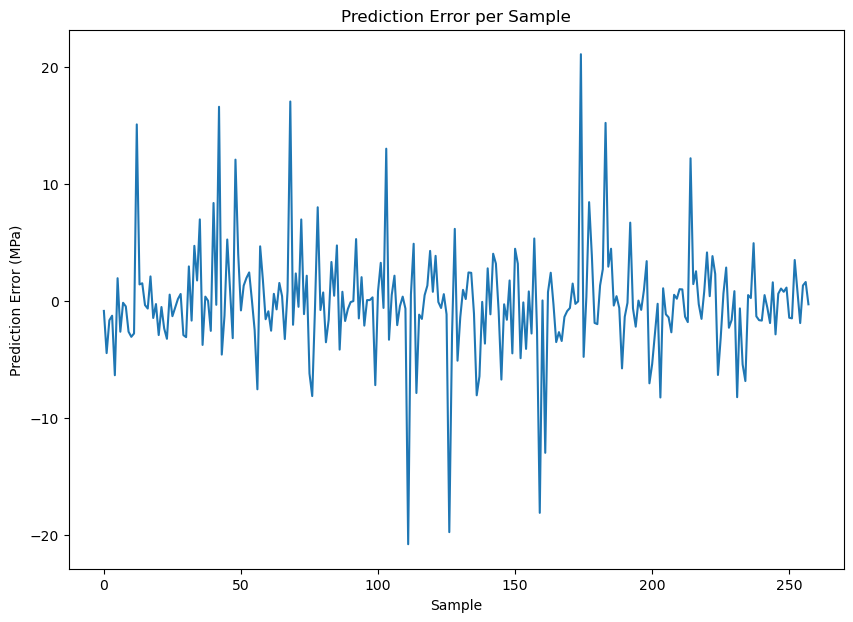

In [136]:
X_test_for_eval = ann_datasets_dict["X Test Data"]
Y_test_for_eval = ann_datasets_dict["Y Test Data"]

X_test_scaled = x_scaler.transform(X_test_for_eval)

y_pred = model.predict(X_test_scaled)

y_test = Y_test_for_eval.values
y_pred_sc = y_scaler.inverse_transform(y_pred)

err = y_pred_sc - y_test

mae = mean_absolute_error(y_test, y_pred_sc)
mse = mean_squared_error(y_test, y_pred_sc)
r2 = r2_score(y_test, y_pred_sc)

print(f"MAE:  {mae:.4f} MPa")
print(f"MSE:  {mse:.4f} MPa²")
print(f"RMSE: {np.sqrt(mse):.4f} MPa")
print(f"R²:   {r2:.4f}")

fig, ax = plt.subplots(1, 1, figsize=[10, 7])
ax.plot(range(len(err)), err)
ax.set_xlabel("Sample")
ax.set_ylabel("Prediction Error (MPa)")
ax.set_title("Prediction Error per Sample")
plt.show()